In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="4k5EHt4LfkvOxqjoflmJ")
project = rf.workspace("hand-gestures").project("hand-gestures-qm0dt")
version = project.version(2)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 99.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Hand-Gestures-2 in yolov8:: 100%|██████████| 1978/1978 [00:00<00:00, 9723.56it/s] 


In [ ]:
import os
!pip install ultralytics
from ultralytics import YOLO

# Note: The FileNotFoundError in cell fUFWii-cLjg7 is due to an incorrect path.
# The correct path for 'best.pt' should be '/content/runs/detect/yolo-ppe2/weights/best.pt'.
# Please update cell fUFWii-cLjg7 with the following line:
# best = YOLO("/content/runs/detect/yolo-ppe2/weights/best.pt")
# You can verify the file existence using os.listdir() if needed:
# print(os.listdir('/content/runs/detect/yolo-ppe2'))
# print(os.listdir('/content/runs/detect/yolo-ppe2/weights'))

In [ ]:

DATA_YML="Hand-Gestures-2/data.yaml"
model = YOLO("yolov8n.pt")


In [ ]:
  model.train(data=DATA_YML, epochs=15, imgsz=640, batch = 16 , name= "yolo-ppe", optimizer = "adam")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Hand-Gestures-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo-ppe2, nbs=64, nms=False, opset=None, optimize=False, optimizer=adam, overlap_mask=True, patience=100, perspective

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7eae3e5055e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [ ]:
best = YOLO("/content/runs/detect/yolo-ppe2/weights/best.pt")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


image 1/1 /content/Hand-Gestures-2/test/images/1B5195B9-5C03-45A8-B8D1-4A30416E8F57_jpg.rf.5a5c28fd47936bd232e2b449828557e0.jpg: 640x640 1 -----, 45.2ms
Speed: 7.4ms preprocess, 45.2ms inference, 8.0ms postprocess per image at shape (1, 3, 640, 640)


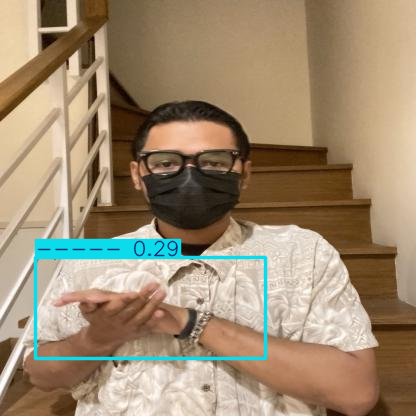

In [ ]:
result = best.predict(source="/content/Hand-Gestures-2/test/images/1B5195B9-5C03-45A8-B8D1-4A30416E8F57_jpg.rf.5a5c28fd47936bd232e2b449828557e0.jpg")
result[0].show()